# T1–T2 synthetic data: coverage, ambiguity, and scale

This notebook answers three concrete questions with the generated dataset itself:

1. What does one 64-point signed measurement contain?
2. How much of parameter space and signal space is covered by 50k, 100k, 200k and 1M voxels?
3. When does the smallest compartment become hard to distinguish from noise?

The audit notebook remains the correctness gate. This notebook is descriptive. In particular, the below-noise statistic is a **detectability heuristic, not a formal information-theoretic ceiling**.

In [1]:
import os, sys, json
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from IPython.display import Image, display

from t1t2.physics import load_protocol

DATA = ROOT / 'data' / 'full_1to4'
FIG = ROOT / 'results' / 'data_overview_v2'
FIG.mkdir(parents=True, exist_ok=True)
proto = load_protocol()

COL = {1: '#56B4E9', 2: '#009E73', 3: '#E69F00', 4: '#7B61A8'}
INK, MUTED, GRID = '#222222', '#666666', '#E3E3E3'
mpl.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': MUTED, 'axes.labelcolor': INK, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': GRID, 'grid.linewidth': 0.8, 'font.size': 10,
})

SIGNAL_COLS = [f'S_{i}' for i in range(1, 65)]
SCALES = {'50k': 12_500, '100k': 25_000, '200k': 50_000, '1M': 250_000}

def norm_signal(x):
    x = np.asarray(x, np.float32)
    den = np.max(np.abs(x), axis=1, keepdims=True)
    den[den == 0] = 1
    return x / den

def forward_batch(t1, t2, w, batch=25_000, normalize=True):
    out = np.empty((len(t1), proto.n_points), np.float32)
    ti, te, tr = proto.ti, proto.te, proto.tr
    for start in range(0, len(t1), batch):
        stop = min(start + batch, len(t1))
        a1, a2, aw = t1[start:stop], t2[start:stop], w[start:stop]
        inv = 1 - 2*np.exp(-ti[None, :, None] / a1[:, None, :]) + np.exp(-tr / a1[:, None, :])
        dec = np.exp(-te[None, :, None] / a2[:, None, :])
        out[start:stop] = np.sum(inv * dec * aw[:, None, :], axis=2)
    return norm_signal(out) if normalize else out

def read_split(split, per_n):
    signals, params, snr = {}, {}, {}
    for n in range(1, 5):
        cols = SIGNAL_COLS + ['snr'] + [f'{x}_{i}' for x in ('T1', 'T2', 'w') for i in range(1, n+1)]
        df = pd.read_parquet(DATA / f'n{n}' / f'{split}.parquet', columns=cols).iloc[:per_n]
        signals[n] = norm_signal(df[SIGNAL_COLS].to_numpy(np.float32))
        params[n] = tuple(df[[f'{x}_{i}' for i in range(1, n+1)]].to_numpy(float) for x in ('T1', 'T2', 'w'))
        snr[n] = df['snr'].to_numpy(float)
    return signals, params, snr

def fit_pca(x):
    mean = x.mean(axis=0)
    cov = np.cov(x - mean, rowvar=False)
    values, vectors = np.linalg.eigh(cov)
    order = np.argsort(values)[::-1]
    values, vectors = values[order], vectors[:, order]
    return mean, vectors, values / values.sum()

def pca_transform(x, mean, vectors, d):
    return ((x - mean) @ vectors[:, :d]).astype(np.float32)

print(f'data: {DATA}')
print(f'protocol: {proto.n_points} measurements = {len(np.unique(proto.ti))} TI × {len(np.unique(proto.te))} TE')

data: /Users/fatihozkan/Desktop/Thesis/t1t2_component_detection/data/full_1to4
protocol: 64 measurements = 8 TI × 8 TE


## 1. Dataset at a glance

The four compartment-count strata are kept separate on disk and combined only by the loader. This gives exact balance and makes every scale arm a nested, reproducible subset.

In [2]:
train_s, train_p, train_snr = read_split('train', 250_000)
test_s, test_p, _ = read_split('test', 10_000)

rows = []
for split in ('train', 'val', 'test'):
    counts = [len(pd.read_parquet(DATA / f'n{n}' / f'{split}.parquet', columns=['n_comp'])) for n in range(1, 5)]
    rows.append({'split': split, **{f'n={n}': v for n, v in zip(range(1, 5), counts)}, 'total': sum(counts)})
display(pd.DataFrame(rows).style.format(thousands=','))
print('Training compartments:', f"{sum(n * len(train_p[n][0]) for n in range(1, 5)):,}")

,split,n=1,n=2,n=3,n=4,total
0,train,"250,000","250,000","250,000","250,000","1,000,000"
1,val,"25,000","25,000","25,000","25,000","100,000"
2,test,"25,000","25,000","25,000","25,000","100,000"


Training compartments: 2,500,000


## 2. One voxel: compartments → signed 8×8 measurement

The scanner never observes the compartment markers. It receives the signed TI×TE grid. The line panel preserves the physical TE axis; acquisition points are not sorted into a fictitious time series.

n=2, SNR=88.4, negative measurements=51/64


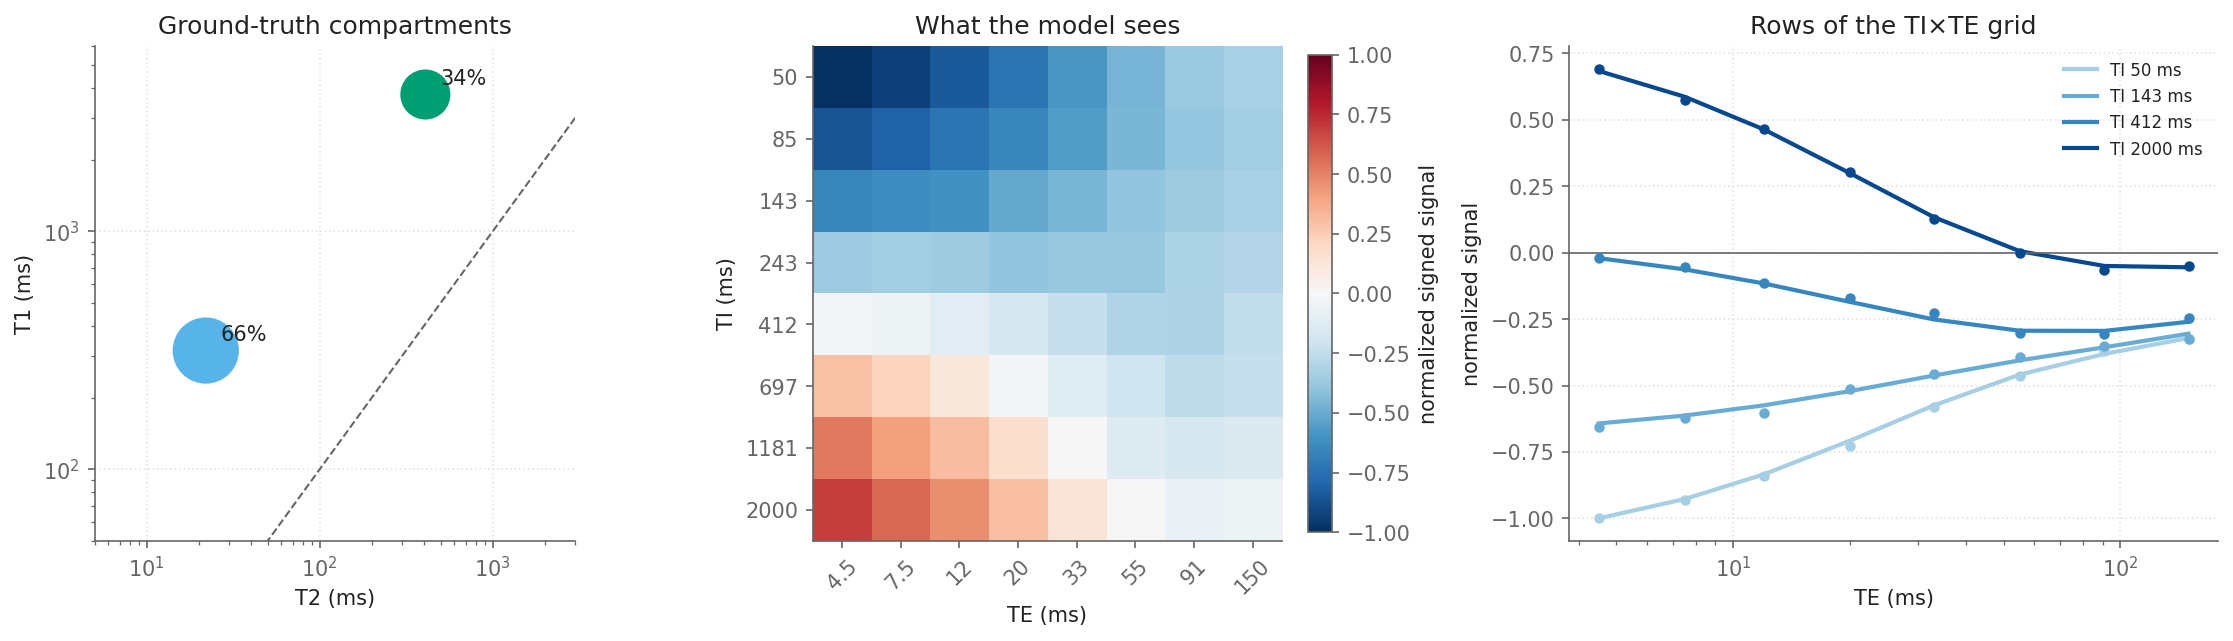

In [3]:
n, idx = 2, 3
t1, t2, w = (x[idx] for x in train_p[n])
observed = train_s[n][idx]
clean = forward_batch(t1[None], t2[None], w[None])[0]
uti, ute = np.unique(proto.ti), np.unique(proto.te)

def signal_grid(sig):
    grid = np.full((len(uti), len(ute)), np.nan)
    for p, value in enumerate(sig):
        i = int(np.argmin(np.abs(uti - proto.ti[p])))
        j = int(np.argmin(np.abs(ute - proto.te[p])))
        grid[i, j] = value
    return grid

g_obs, g_clean = signal_grid(observed), signal_grid(clean)
fig, ax = plt.subplots(1, 3, figsize=(15, 4.4), gridspec_kw={'width_ratios': [1, 1.08, 1.35]})

ax[0].scatter(t2, t1, s=180 + 1400*w, c=[COL[i+1] for i in range(n)], edgecolor='white', linewidth=1.5)
for i in range(n):
    ax[0].annotate(f'{100*w[i]:.0f}%', (t2[i], t1[i]), xytext=(7, 5), textcoords='offset points')
ax[0].plot([5, 4000], [5, 4000], color=MUTED, lw=1, ls='--')
ax[0].set(xscale='log', yscale='log', xlim=(5, 3000), ylim=(50, 6000), xlabel='T2 (ms)', ylabel='T1 (ms)', title='Ground-truth compartments')
ax[0].grid(True, which='major', ls=':')

im = ax[1].imshow(g_obs, cmap='RdBu_r', norm=TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1), aspect='auto')
ax[1].set(xticks=range(8), yticks=range(8), xlabel='TE (ms)', ylabel='TI (ms)', title='What the model sees')
ax[1].set_xticklabels([f'{x:g}' for x in ute], rotation=45)
ax[1].set_yticklabels([f'{x:g}' for x in uti])
fig.colorbar(im, ax=ax[1], fraction=0.046, label='normalized signed signal')

for i in (0, 2, 4, 7):
    ax[2].plot(ute, g_clean[i], lw=2, color=plt.cm.Blues(0.35 + 0.08*i), label=f'TI {uti[i]:g} ms')
    ax[2].scatter(ute, g_obs[i], s=16, color=plt.cm.Blues(0.35 + 0.08*i), zorder=3)
ax[2].axhline(0, color=MUTED, lw=0.8)
ax[2].set(xscale='log', xlabel='TE (ms)', ylabel='normalized signal', title='Rows of the TI×TE grid')
ax[2].grid(True, ls=':'); ax[2].legend(fontsize=8, frameon=False)

fig.tight_layout(); path = FIG / '01_voxel_and_protocol.png'; fig.savefig(path, dpi=150, bbox_inches='tight'); plt.close(fig)
print(f'n={n}, SNR={train_snr[n][idx]:.1f}, negative measurements={(observed < 0).sum()}/64')
Image(filename=str(path))

## 3. Does 1M cover more space than 100k?

Two complementary definitions are used:

- **Parameter coverage:** occupied cells and held-out nearest distance in normalized log(T1)–log(T2).
- **Signal coverage:** held-out clean signal's nearest training signal after projecting onto enough PCA components to retain 99.9% of clean-signal variance.

The signal metric measures density, not model accuracy. All arms use the same held-out queries.

,scale,voxels,pools,grid128_%,grid128_empty,param_nn_med,param_nn_p90,signal_rms_med_%,signal_rms_p90_%,signal_rms_p99_%,steps_per_epoch
0,50k,50000,125000,99.9913,1,0.001120,0.002044,1.62,3.00,4.45,98
1,100k,100000,250000,100.0000,0,0.000787,0.001441,1.43,2.69,4.00,196
2,200k,200000,500000,100.0000,0,0.000556,0.001013,1.27,2.40,3.61,391
3,1M,1000000,2500000,100.0000,0,0.000248,0.000452,0.96,1.88,2.85,1954


Clean-signal PCA dimensions: 95%=3, 99%=6, 99.9%=10


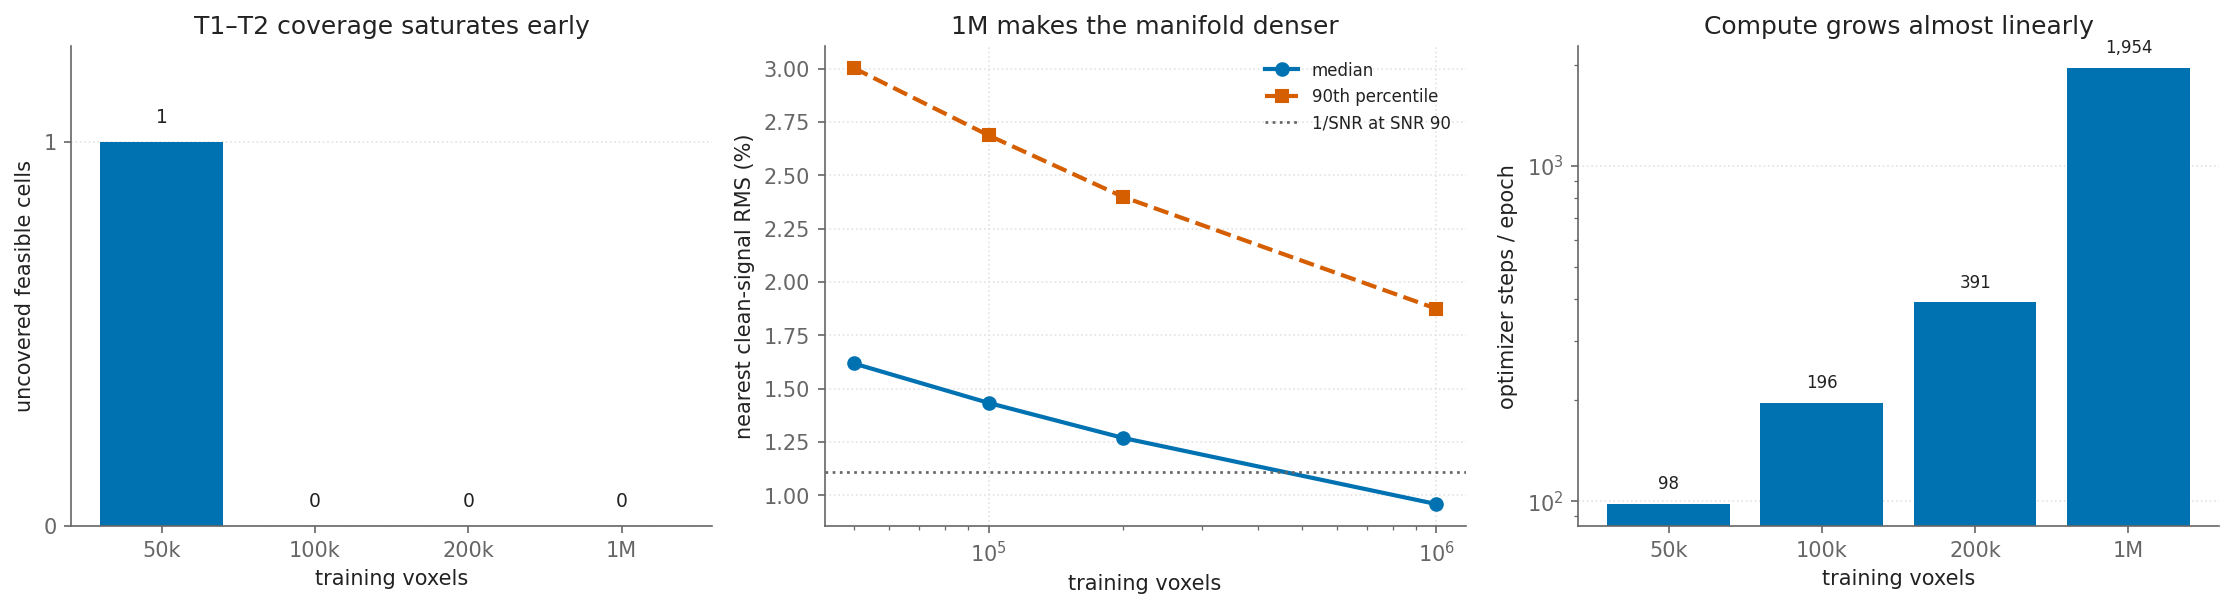

In [4]:
def pool_points(params, per_n):
    lo1, hi1 = np.log(50), np.log(4000)
    lo2, hi2 = np.log(5), np.log(3000)
    points = []
    for n, (t1, t2, _) in params.items():
        points.append(np.column_stack(((np.log(t1[:per_n]).ravel()-lo1)/(hi1-lo1), (np.log(t2[:per_n]).ravel()-lo2)/(hi2-lo2))))
    return np.concatenate(points)

def grid_occupancy(points, bins=128):
    ix = np.clip((points[:, 0] * bins).astype(int), 0, bins-1)
    iy = np.clip((points[:, 1] * bins).astype(int), 0, bins-1)
    occupied = set((ix*bins + iy).tolist())
    gx, gy = np.meshgrid((np.arange(bins)+0.5)/bins, (np.arange(bins)+0.5)/bins, indexing='ij')
    l1 = np.log(50) + gx*(np.log(4000)-np.log(50))
    l2 = np.log(5) + gy*(np.log(3000)-np.log(5))
    feasible = set(np.flatnonzero((l2 < l1).ravel()).tolist())
    hit = len(occupied & feasible)
    return hit / len(feasible), len(feasible) - hit

def nearest_stats(train, test):
    d, _ = cKDTree(train).query(test, k=1, workers=-1)
    return np.median(d), np.quantile(d, 0.9), np.quantile(d, 0.99)

test_pool = pool_points(test_p, 10_000)
param_rows = []
for label, per_n in SCALES.items():
    pts = pool_points(train_p, per_n)
    med, p90, p99 = nearest_stats(pts, test_pool)
    occupancy, empty = grid_occupancy(pts)
    param_rows.append({'scale': label, 'voxels': per_n*4, 'pools': len(pts), 'grid128_%': 100*occupancy, 'grid128_empty': empty, 'param_nn_med': med, 'param_nn_p90': p90})
param_df = pd.DataFrame(param_rows)

clean_100k = np.concatenate([forward_batch(*(x[:25_000] for x in train_p[n])) for n in range(1, 5)])
pca_mean, pca_vec, pca_var = fit_pca(clean_100k)
cumvar = np.cumsum(pca_var)
d95, d99, d999 = [int(np.searchsorted(cumvar, x)+1) for x in (0.95, 0.99, 0.999)]
test_clean = np.concatenate([forward_batch(*test_p[n]) for n in range(1, 5)])
test_z = pca_transform(test_clean, pca_mean, pca_vec, d999)

train_z = {}
for n in range(1, 5):
    train_z[n] = pca_transform(forward_batch(*train_p[n]), pca_mean, pca_vec, d999)

signal_rows = []
for label, per_n in SCALES.items():
    z = np.concatenate([train_z[n][:per_n] for n in range(1, 5)])
    med, p90, p99 = nearest_stats(z, test_z)
    signal_rows.append({'scale': label, 'signal_rms_med_%': 100*med/np.sqrt(64), 'signal_rms_p90_%': 100*p90/np.sqrt(64), 'signal_rms_p99_%': 100*p99/np.sqrt(64), 'steps_per_epoch': int(np.ceil(per_n*4/512))})
signal_df = pd.DataFrame(signal_rows)
coverage = param_df.merge(signal_df, on='scale')
display(coverage.style.format({'grid128_%': '{:.4f}', 'param_nn_med': '{:.6f}', 'param_nn_p90': '{:.6f}', 'signal_rms_med_%': '{:.2f}', 'signal_rms_p90_%': '{:.2f}', 'signal_rms_p99_%': '{:.2f}'}))
print(f'Clean-signal PCA dimensions: 95%={d95}, 99%={d99}, 99.9%={d999}')

x = coverage['voxels'].to_numpy()
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

bars0 = ax[0].bar(coverage['scale'], coverage['grid128_empty'], color='#0072B2')
for b, v in zip(bars0, coverage['grid128_empty']):
    ax[0].text(b.get_x()+b.get_width()/2, v+0.04, str(int(v)), ha='center', va='bottom', fontsize=9)
ax[0].set(ylim=(0, 1.25), xlabel='training voxels', ylabel='uncovered feasible cells', title='T1–T2 coverage saturates early', yticks=[0, 1])
ax[0].grid(True, axis='y', ls=':'); ax[0].set_axisbelow(True)

ax[1].plot(x, coverage['signal_rms_med_%'], 'o-', color='#0072B2', lw=2, label='median')
ax[1].plot(x, coverage['signal_rms_p90_%'], 's--', color='#D55E00', lw=2, label='90th percentile')
ax[1].axhline(100/90, color=MUTED, ls=':', lw=1.3, label='1/SNR at SNR 90')
ax[1].set(xscale='log', xlabel='training voxels', ylabel='nearest clean-signal RMS (%)', title='1M makes the manifold denser')
ax[1].grid(True, ls=':'); ax[1].legend(frameon=False, fontsize=8)

bars = ax[2].bar(coverage['scale'], coverage['steps_per_epoch'], color='#0072B2')
ax[2].set(yscale='log', xlabel='training voxels', ylabel='optimizer steps / epoch', title='Compute grows almost linearly')
for b, v in zip(bars, coverage['steps_per_epoch']):
    ax[2].text(b.get_x()+b.get_width()/2, v*1.08, f'{v:,}', ha='center', va='bottom', fontsize=8)
ax[2].grid(True, axis='y', ls=':'); ax[2].set_axisbelow(True)

fig.tight_layout(); path = FIG / '02_scale_coverage.png'; fig.savefig(path, dpi=150, bbox_inches='tight'); plt.close(fig)
Image(filename=str(path))

## 4. The 64-number signal lives on a low-dimensional manifold

PCA is used only as a descriptive coordinate system. Strong overlap between compartment-count contours explains why count prediction is difficult, but it is not itself an identifiability proof.

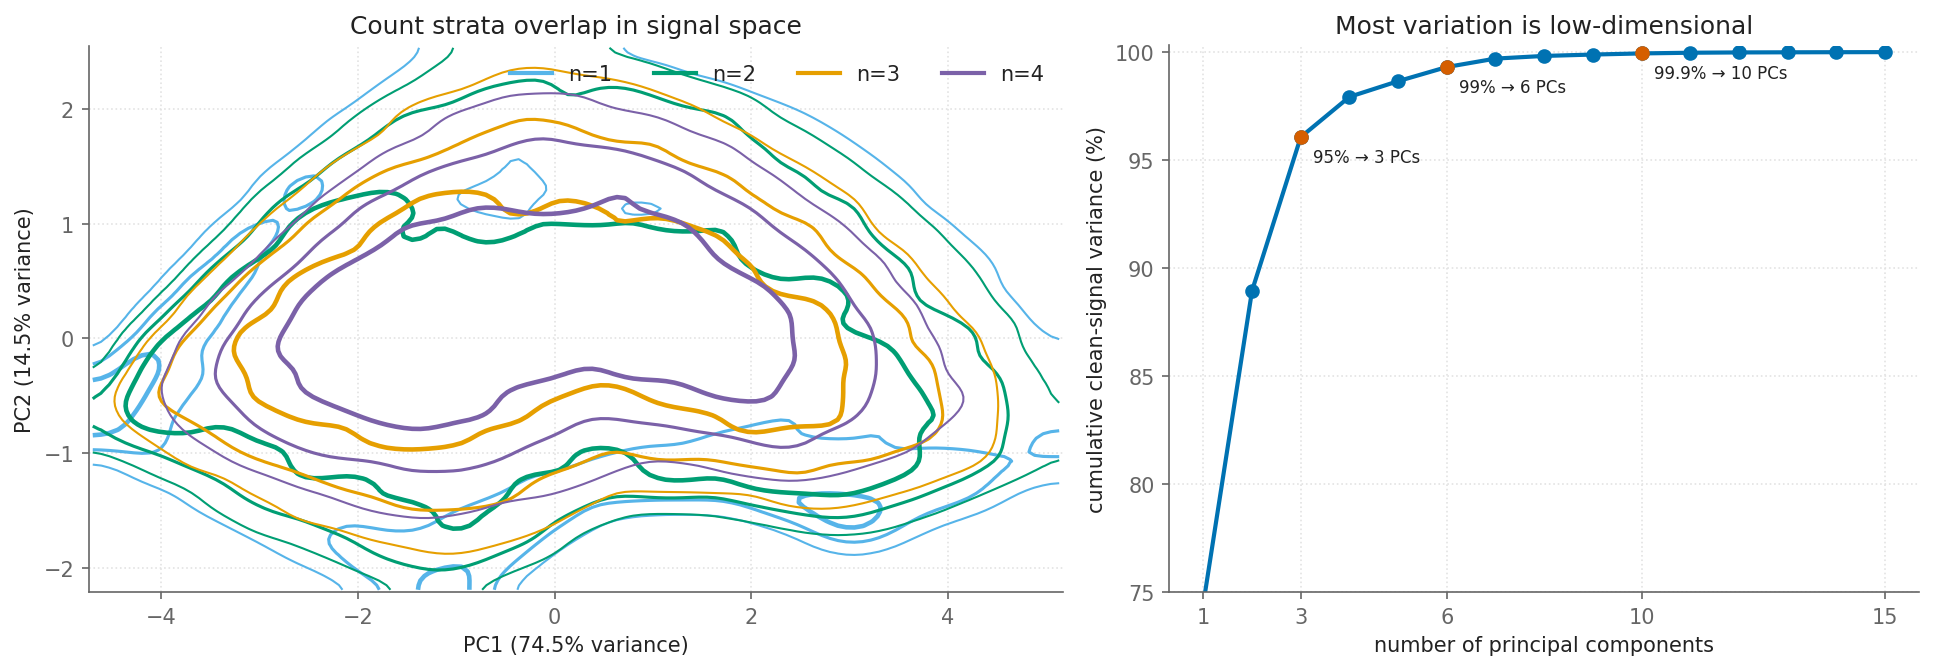

In [5]:
z2 = {n: pca_transform(forward_batch(*(x[:25_000] for x in train_p[n])), pca_mean, pca_vec, 2) for n in range(1, 5)}
all_z = np.concatenate(list(z2.values()))
xmin, ymin = np.quantile(all_z, 0.001, axis=0)
xmax, ymax = np.quantile(all_z, 0.999, axis=0)
xbins, ybins = np.linspace(xmin, xmax, 120), np.linspace(ymin, ymax, 120)
xc, yc = (xbins[:-1]+xbins[1:])/2, (ybins[:-1]+ybins[1:])/2

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={'width_ratios': [1.3, 1]})
for n in range(1, 5):
    h, _, _ = np.histogram2d(z2[n][:, 0], z2[n][:, 1], bins=(xbins, ybins))
    h = gaussian_filter(h, 3.0)
    levels = h.max() * np.array([0.12, 0.35, 0.65])
    ax[0].contour(xc, yc, h.T, levels=levels, colors=[COL[n]], linewidths=[1.0, 1.5, 2.2])
    ax[0].plot([], [], color=COL[n], lw=2, label=f'n={n}')
ax[0].set(xlim=(xmin, xmax), ylim=(ymin, ymax), xlabel=f'PC1 ({100*pca_var[0]:.1f}% variance)', ylabel=f'PC2 ({100*pca_var[1]:.1f}% variance)', title='Count strata overlap in signal space')
ax[0].grid(True, ls=':'); ax[0].legend(frameon=False, ncol=4)

k = np.arange(1, 16)
ax[1].plot(k, 100*cumvar[:15], 'o-', color='#0072B2', lw=2)
for d, target in ((d95, 95), (d99, 99), (d999, 99.9)):
    ax[1].scatter([d], [100*cumvar[d-1]], color='#D55E00', zorder=3)
    ax[1].annotate(f'{target}% → {d} PCs', (d, 100*cumvar[d-1]), xytext=(6, -12), textcoords='offset points', fontsize=8)
ax[1].set(xlabel='number of principal components', ylabel='cumulative clean-signal variance (%)', title='Most variation is low-dimensional', xticks=[1, 3, 6, 10, 15], ylim=(75, 100.3))
ax[1].grid(True, ls=':')

fig.tight_layout(); path = FIG / '03_signal_manifold.png'; fig.savefig(path, dpi=150, bbox_inches='tight'); plt.close(fig)
Image(filename=str(path))

## 5. Noise difficulty across the full SNR range

For each multi-compartment voxel, remove the smallest-weight compartment, renormalize the remaining weights, and compare the median absolute signal change with one noise standard deviation. The reported fraction satisfies `median(|Δsignal|) < σ`.

This is a useful, reproducible difficulty proxy. It is **not** a Cramér–Rao bound and must not be described as the maximum possible count accuracy. The final column uses each training voxel's actual random SNR; SNR 20 is shown separately as out-of-distribution stress testing.

,20,30,40,60,100,150,train mix
n=2,29.2%,19.6%,14.3%,8.8%,4.6%,2.7%,6.7%
n=3,51.4%,33.8%,23.5%,12.9%,5.8%,2.8%,9.7%
n=4,69.1%,48.3%,34.0%,18.3%,6.9%,2.8%,13.1%


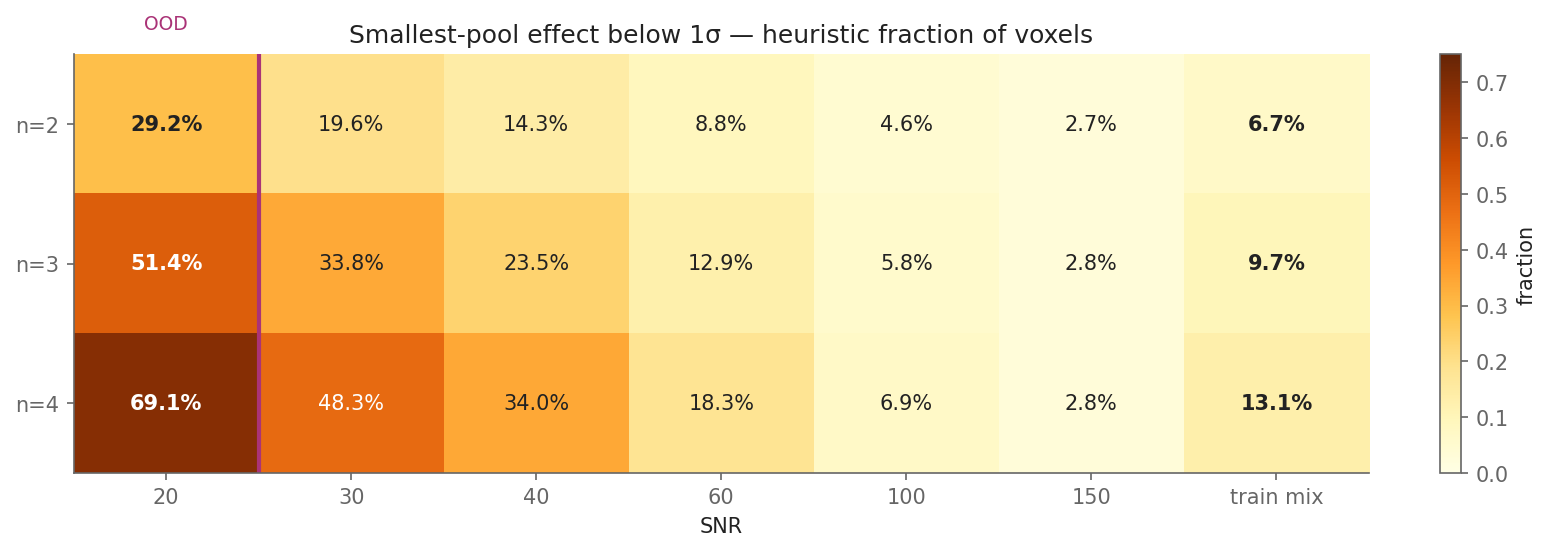

In [6]:
SNR_LEVELS = [20, 30, 40, 60, 100, 150]
fractions, median_ratio = [], []
for n in (2, 3, 4):
    t1, t2, w = (x[:25_000] for x in train_p[n])
    keep = np.argsort(w, axis=1)[:, 1:]
    t1r = np.take_along_axis(t1, keep, axis=1)
    t2r = np.take_along_axis(t2, keep, axis=1)
    wr = np.take_along_axis(w, keep, axis=1)
    wr = wr / wr.sum(axis=1, keepdims=True)
    full = forward_batch(t1, t2, w, normalize=False)
    reduced = forward_batch(t1r, t2r, wr, normalize=False)
    q = np.median(np.abs(full-reduced), axis=1) / np.max(np.abs(full), axis=1)
    row = [np.mean(q*snr < 1) for snr in SNR_LEVELS]
    row.append(np.mean(q*train_snr[n][:25_000] < 1))
    fractions.append(row)
    median_ratio.append([np.median(q*snr) for snr in SNR_LEVELS] + [np.median(q*train_snr[n][:25_000])])
fractions = np.asarray(fractions)

labels = [str(x) for x in SNR_LEVELS] + ['train mix']
fig, ax = plt.subplots(figsize=(10.5, 3.8))
im = ax.imshow(fractions, cmap='YlOrBr', vmin=0, vmax=0.75, aspect='auto')
ax.set(xticks=range(len(labels)), xticklabels=labels, yticks=range(3), yticklabels=['n=2', 'n=3', 'n=4'], xlabel='SNR', title='Smallest-pool effect below 1σ — heuristic fraction of voxels')
for i in range(fractions.shape[0]):
    for j in range(fractions.shape[1]):
        v = fractions[i, j]
        ax.text(j, i, f'{100*v:.1f}%', ha='center', va='center', color='white' if v > 0.42 else INK, fontweight='bold' if j in (0, 6) else 'normal')
ax.axvline(0.5, color='#AA3377', lw=2)
ax.text(0, -0.68, 'OOD', color='#AA3377', ha='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.035, label='fraction')
fig.tight_layout(); path = FIG / '04_detectability_by_snr.png'; fig.savefig(path, dpi=150, bbox_inches='tight'); plt.close(fig)
display(pd.DataFrame(100*fractions, index=['n=2', 'n=3', 'n=4'], columns=labels).style.format('{:.1f}%'))
Image(filename=str(path))

## 6. Dataset-size decision

The measured trade-off is now explicit:

- 100k already fills the feasible T1–T2 grid at 128×128 resolution.
- 1M reduces the median held-out clean-signal coverage distance by roughly one third.
- 1M costs approximately ten times as many optimizer steps per epoch.
- More samples from the same simulator do not solve the synthetic-to-real gap.

Recommended sequence: **100k first → 200k if validation improves materially → 1M as an optional upper-bound arm**. Keep the 1M files because all smaller arms are nested subsets; there is no need to regenerate data.

After training, add one final figure here: validation/test count accuracy and T1/T2 error versus both unique training voxels and wall time. Coverage alone cannot choose the winning model.